In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from functions import Functions

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [4]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [5]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [ ]:
extent = [138, 150,-68,-64]


mertz = Region('Mertz',extent)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [7]:
# set up lines of constant density

def sig0range(tlims,slims):
    sig0_n = 100
    temprange = np.linspace(tlims[0],tlims[1],sig0_n)
    psalrange = np.linspace(slims[0],slims[1],sig0_n)

    sig0range = np.zeros((sig0_n,sig0_n))
    for i,t in enumerate(temprange):
        for j,s in enumerate(psalrange):
            sig0range[i,j]=gsw.sigma0(gsw.conversions.SA_from_SP(s,0,145,-67),gsw.CT_from_t(s,t,0))
    return temprange,psalrange,sig0range


In [8]:
#ds = pickle.load(open('c3data.pkl','rb'))

In [9]:
ds = xr.open_dataset(fname_spira).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [12]:
meop=MEOP(extent=extent)


In [13]:
meop.load_profiles_for_spira()

  0%|          | 0/84 [00:00<?, ?it/s]

100%|██████████| 84/84 [00:58<00:00,  1.43it/s]


In [14]:
# get new seals data (recorded after Spira cutoff date)
seals = meop.ds.sortby('time').sel(time=slice(ds.time[-1],pd.Timestamp(2026,1,1)))

# filter silly values
seals = seals.where(~((seals.psal < 30) | (seals.psal > 36)))

In [15]:
seals25 = seals.where(seals.pres < 25,drop=True)
seals300 = seals.where(seals.pres < 300,drop=True)

In [16]:
# make sure there is a value above 25dbar
keep = []
for t in seals.time:
    tmp25 = seals25.sel(time=t)
    tmp300 = seals300.sel(time=t)
    boo25 = np.any(~np.isnan(seals25.temp) & ~np.isnan(seals25.psal))
    boo300 = (~np.isnan(seals300.temp) & ~np.isnan(seals300.psal)).sum() > 5
    keep.append(boo25.item() & boo300.item())
print('kept {0} of {1} profiles'.format(np.array(keep).sum(),len(seals.time)))

kept 1698 of 1698 profiles


In [17]:
ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])

/tmp/ipykernel_844633/1968367709.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])
/tmp/ipykernel_844633/1968367709.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])
/tmp/ipykernel_844633/1968367709.p

In [18]:
ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])
ds['month'] = ds.time.dt.month
ds['year'] = ds.time.dt.year
ds['asal'] = gsw.conversions.SA_from_SP(ds.psal,ds.pres,145,ds.lat)
ds['ctemp'] = gsw.conversions.CT_from_t(ds.asal,ds.temp,ds.pres)
ds['rho'] = gsw.density.rho(ds.asal,ds.ctemp,ds.pres)
ds['sigma0'] = gsw.density.sigma0(ds.asal,ds.ctemp)


/tmp/ipykernel_844633/3283920528.py:1: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])


In [19]:
with open('c3data.pkl', 'wb') as file:
    pickle.dump(ds, file)

In [37]:
# optionally chop ds further
#extent = [139.5, 144, -68, -65.75]
extent = [139.5, 143, -68, -66.25]
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [38]:
ds_shelf = ds.where(ds.elevation > -1000,drop=True)

In [39]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons

seasons = get_seasons(ds_shelf)
seasons_all = get_seasons(ds)



In [40]:
ds_400 = ds_shelf.sel(pres=slice(0,400)).mean('pres')

In [41]:
mon_mean = ds_400.resample({'time':'MS'}).mean()
mon_std = ds_400.resample({'time':'MS'}).std()
mon_count = ds_400.resample({'time':'MS'}).count()

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [42]:
cli_mean = mon_mean.groupby('time.month').mean()
cli_count = mon_mean.groupby('time.month').count()
cli_std = mon_mean.groupby('time.month').std()

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [43]:
df=mon_mean.to_dataframe()

In [44]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this ob

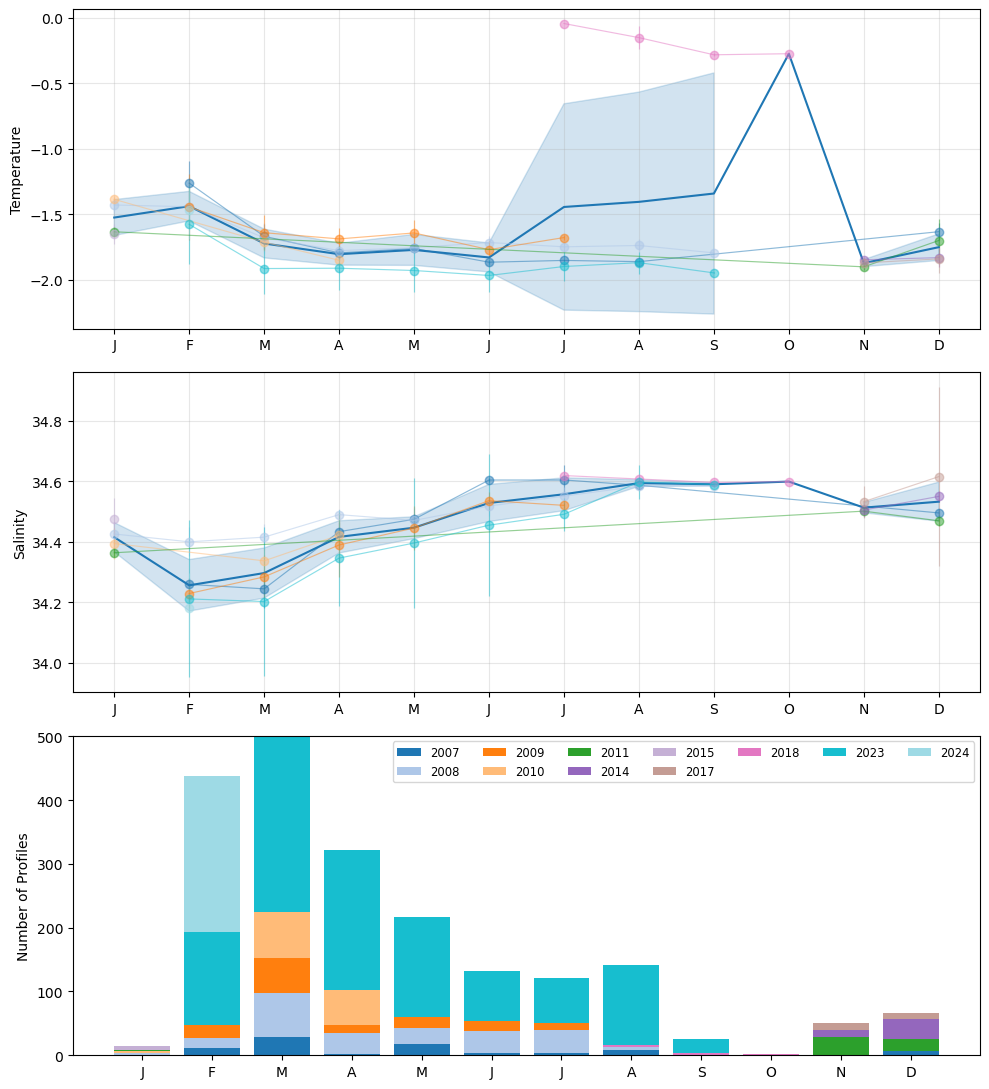

In [45]:
# # plot to demonstrate types of variailty
# dscrop = ds_400.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2008,1,1)))
# dscropmon = dscrop.groupby('time.month').mean()
# dscropmonstd = dscrop.groupby('time.month').std()

# fig,axs = plt.subplots(2,1,figsize=(10,5))
# ax=axs[0]
# ax.scatter(dscrop.month,dscrop.temp)
# ax.errorbar(dscropmon.month,dscropmon.temp,yerr=dscropmonstd.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# ax=axs[1]
# ax.scatter(mon_mean.month,mon_mean.temp)
# ax.errorbar(cli_mean.month,cli_mean.temp,yerr=cli_std.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# plt.tight_layout()

# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.groupby('time.year').count()

colors = plt.cm.tab20(np.linspace(0, 1, len(mon_year.year)))

ax=axs[0]
cx=axs[1]
bx=axs[2]

for y,c in zip(mon_year.year,colors):
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)
    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean()
        clis = dats.groupby('time.month').mean()

        # temperature
        ax.errorbar(clim.month,clim.temp,yerr=clis.temp,marker='o',alpha=0.5,linewidth=0.85,c=c)
        
        # salinity
        cx.errorbar(clim.month,clim.psal,yerr=clis.psal,marker='o',alpha=0.5,linewidth=0.85,c=c)

        # histogram
        year_count = np.nan_to_num(mon_count.temp.where(mon_mean.year==y,drop=True).groupby('time.month').mean().broadcast_like(cli_mean.month))
        if y > 2007:
            bx.bar(cli_mean.month, year_count, bottom = bottom,color=c,label=str(y.item()))
            bottom = bottom + year_count
        else:
            bx.bar(cli_mean.month, year_count,color=c,label=str(y.item()))
            bottom = year_count.copy()
        

#ax.legend(loc='best',fontsize=2)
bx.legend(ncol=7,fontsize='small')
bx.set_ylabel('Number of Profiles')
bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="temp", errorbar="sd", ax=ax
)
  
sns.lineplot(
    data=df,
    x="month", y="psal", errorbar="sd", ax=cx
)

ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('Temperature')
ax.set_xlabel(None)

cx.grid(alpha=0.3)
cx.set_xticks(np.arange(1,13),labels=month_labels)
cx.set_ylabel('Salinity')
cx.set_xlabel(None)

plt.tight_layout()



In [46]:
mon_mean = ds_shelf.resample({'time':'MS'}).mean()
mon_std = ds_shelf.resample({'time':'MS'}).std()

cli_mean = mon_mean.groupby('time.month').mean()
cli_count = mon_mean.groupby('time.month').count()
cli_std = mon_mean.groupby('time.month').std()

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

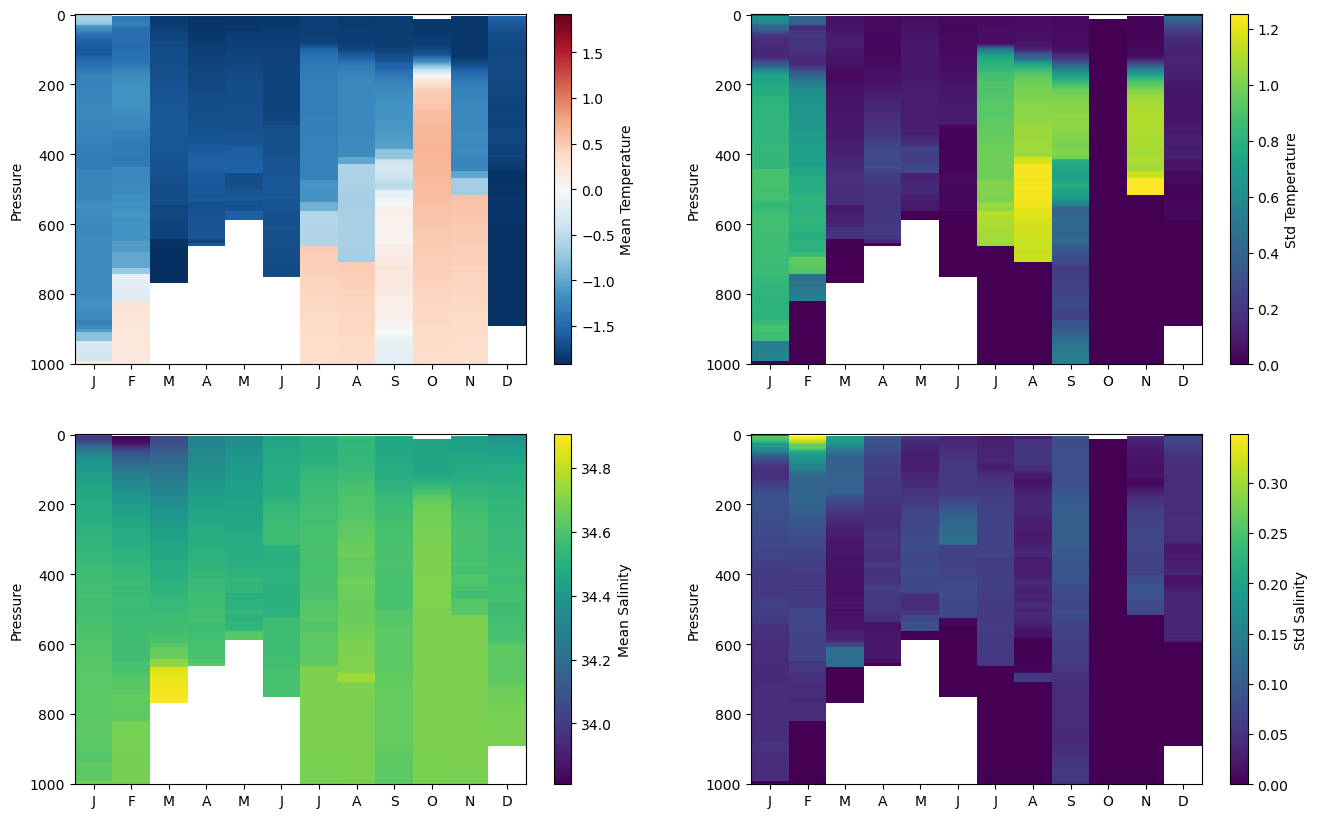

: 

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(16,10))

def presvmonth(ax,data,label):
    im=data.plot(ax=ax,x='month',y='pres')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    im.colorbar.set_label(label)
    ax.set_xticks(np.arange(1,13),labels=month_labels)
    ax.set_xlabel(None)


presvmonth(ax[0][0],cli_mean.temp,'Mean Temperature')
presvmonth(ax[0][1],cli_std.temp,'Std Temperature')

presvmonth(ax[1][0],cli_mean.psal,'Mean Salinity')
presvmonth(ax[1][1],cli_std.psal,'Std Salinity')


In [ ]:
cdict = dict(zip(year_count.year.to_numpy,colors))


2020

: 

In [152]:
ds_shelf

<xarray.Dataset> Size: 92MB
Dimensions:       (time: 2539, pres: 501)
Coordinates:
  * time          (time) datetime64[ns] 20kB 2007-02-20T23:29:59.000002 ... 2...
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
    lon           (time) float64 20kB 140.0 140.0 140.0 ... 140.0 139.8 139.8
    lat           (time) float64 20kB -66.56 -66.58 -66.66 ... -66.61 -66.61
    n_prof        (time) float64 20kB 7.932e+05 7.932e+05 7.932e+05 ... nan nan
Data variables: (12/14)
    temp          (time, pres) float64 10MB nan nan nan -1.339 ... nan nan nan
    psal          (time, pres) float64 10MB nan nan nan 33.86 ... nan nan nan
    dsource       (time, pres) object 10MB 'MEOP' 'MEOP' ... 'MEOP-' 'MEOP-'
    mld           (time) float64 20kB 65.34 17.82 49.5 49.5 ... nan nan nan nan
    asal          (time, pres) float64 10MB nan nan nan 34.02 ... nan nan nan
    ctemp         (time, pres) float64 10MB nan nan nan -1.335 ... nan nan nan
    ...            ...
    profile_code  (time, pres) object 10MB nan nan ... 'wd30-639-Vert-22'
    gph           (time, pres) float64 10MB nan nan nan nan ... nan nan nan nan
    elevation     (time) float64 20kB -296.9 -96.14 -499.0 ... -105.2 -133.7
    month         (time) float64 20kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0
    year          (time) float64 20kB 2.007e+03 2.007e+03 ... 2.024e+03
    sigma0        (time, pres) float64 10MB nan nan nan 27.24 ... nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [149]:
year_count = ds_shelf.groupby('time.year').count()

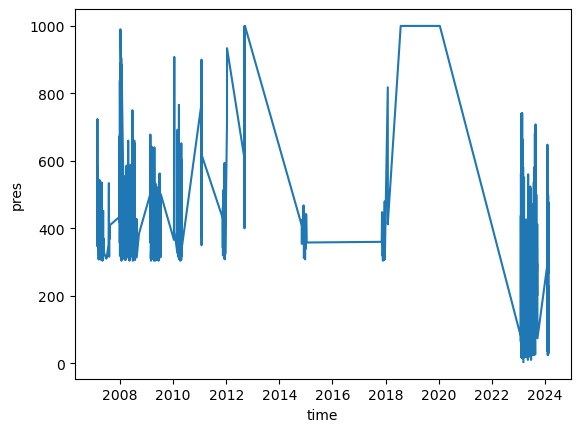

In [164]:
max_depth = ds_shelf.pres.where(~np.isnan(ds_shelf.temp)).max(dim="pres")
max_depth.plot()

/tmp/ipykernel_14313/2311218991.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  im=ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()])
/tmp/ipykernel_14313/2311218991.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  im=ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()])
/tmp/ipykernel_14313/2311218991.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be av

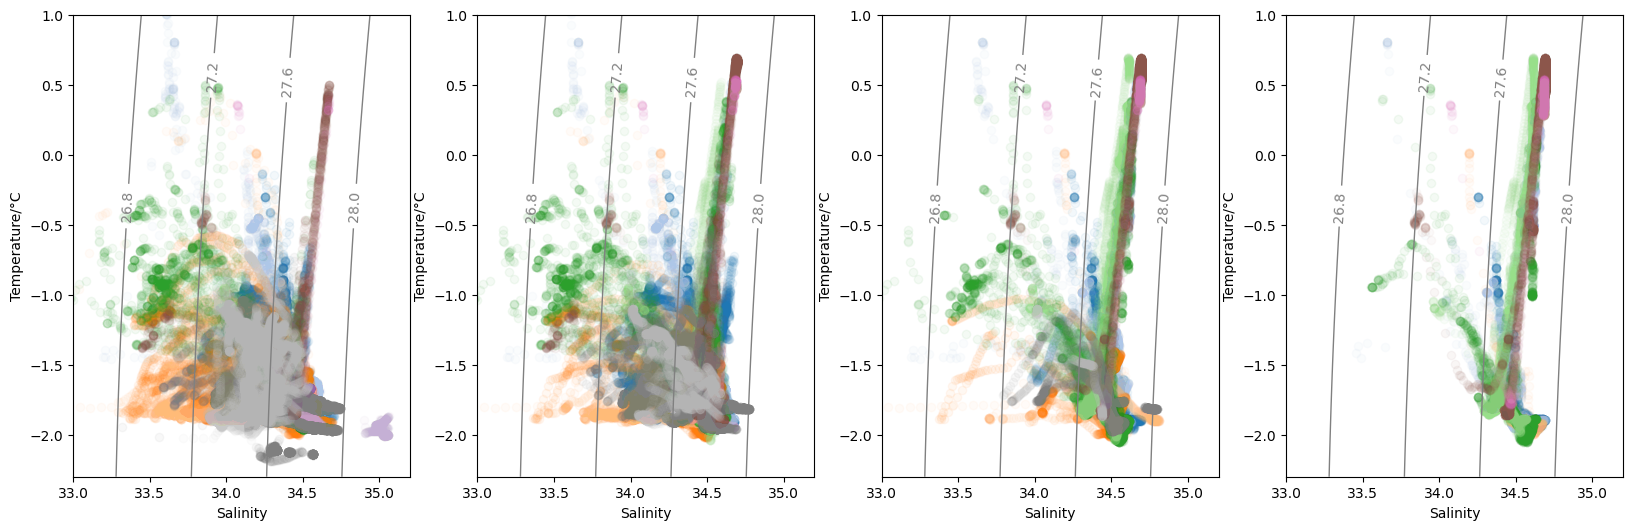

In [167]:
fig, ax = plt.subplots(1,4,figsize=(20,6))

zz=500

def ts_plot(ax,zz):
    for y in year_count.year:
        data = ds_shelf.where(ds_shelf.year==y,drop=True).where(max_depth > zz,drop=True).sel(pres=slice(0,zz))
        if not len(data.time) ==0:
            im=ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()])

            

    tlim=[-2.3,1]
    slim=[33,35.2]
    temprange,psalrange,sig0range_ = sig0range(tlim,slim)
    cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax.set_xlim(slim)
    ax.set_ylim(tlim)
    ax.set_ylabel('Temperature/°C')
    ax.set_xlabel('Salinity')

ts_plot(ax[0],200)
ts_plot(ax[1],400)
ts_plot(ax[2],600)
ts_plot(ax[3],800)
